In [1]:
import os
import csv
from pathlib import Path
from datetime import datetime

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split

from tqdm import tqdm

In [2]:
# ===== paths =====
DATA_DIR = "./collect_2026_03_10_15_04_32"
IMAGE_DIR = os.path.join(DATA_DIR, "images")
LABEL_CSV = os.path.join(DATA_DIR, "labels.csv")

# ===== csv columns =====
# 0: image filename
# 1: control value 1
# 2: control value 2
IMAGE_COL_IDX = 0
TARGET_COL_IDX = 2   # 默认先用第3列；若不对改成 1

# ===== training hyperparameters =====
BATCH_SIZE = 256
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-5
NUM_EPOCHS = 100
TRAIN_RATIO = 0.8
RANDOM_SEED = 42

# ===== device =====
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# ===== model input size =====
INPUT_HEIGHT = 144
INPUT_WIDTH = 224

# ===== result folder =====
RESULT_FOLDER = Path(datetime.now().strftime("cnn_%Y_%m_%d_%H_%M_%S"))
RESULT_FOLDER.mkdir(parents=True, exist_ok=True)

print("DEVICE =", DEVICE)
print("RESULT_FOLDER =", RESULT_FOLDER.resolve())
print("LABEL_CSV exists:", os.path.exists(LABEL_CSV))
print("IMAGE_DIR exists:", os.path.exists(IMAGE_DIR))

DEVICE = cuda
RESULT_FOLDER = /home/yipengliu/TEA_Car/cnn_2026_03_10_21_10_09
LABEL_CSV exists: True
IMAGE_DIR exists: True


In [3]:
rows = []
with open(LABEL_CSV, "r", newline="") as f:
    reader = csv.reader(f)
    for row in reader:
        rows.append(row)

print("Total rows in CSV:", len(rows))
print("First 10 rows:")
for r in rows[:10]:
    print(r)

Total rows in CSV: 9308
First 10 rows:
['1.jpg', '0', '0']
['2.jpg', '0', '0']
['3.jpg', '0', '0']
['4.jpg', '0', '0']
['5.jpg', '0', '0']
['6.jpg', '0', '0']
['7.jpg', '0', '0']
['8.jpg', '0', '0.0521918']
['9.jpg', '0', '0.10877']
['10.jpg', '0', '0.205298']


In [4]:
samples = []

for row in rows:
    if len(row) <= max(IMAGE_COL_IDX, TARGET_COL_IDX):
        continue

    image_name = str(row[IMAGE_COL_IDX]).strip()

    try:
        target = float(row[TARGET_COL_IDX])
    except:
        continue

    full_path = os.path.join(IMAGE_DIR, image_name)
    if not os.path.exists(full_path):
        continue

    samples.append({
        "image_name": image_name,
        "target": target,
        "full_path": full_path
    })

print("Usable samples:", len(samples))
print("First 10 parsed samples:")
for s in samples[:10]:
    print(s)

Usable samples: 9308
First 10 parsed samples:
{'image_name': '1.jpg', 'target': 0.0, 'full_path': './collect_2026_03_10_15_04_32/images/1.jpg'}
{'image_name': '2.jpg', 'target': 0.0, 'full_path': './collect_2026_03_10_15_04_32/images/2.jpg'}
{'image_name': '3.jpg', 'target': 0.0, 'full_path': './collect_2026_03_10_15_04_32/images/3.jpg'}
{'image_name': '4.jpg', 'target': 0.0, 'full_path': './collect_2026_03_10_15_04_32/images/4.jpg'}
{'image_name': '5.jpg', 'target': 0.0, 'full_path': './collect_2026_03_10_15_04_32/images/5.jpg'}
{'image_name': '6.jpg', 'target': 0.0, 'full_path': './collect_2026_03_10_15_04_32/images/6.jpg'}
{'image_name': '7.jpg', 'target': 0.0, 'full_path': './collect_2026_03_10_15_04_32/images/7.jpg'}
{'image_name': '8.jpg', 'target': 0.0521918, 'full_path': './collect_2026_03_10_15_04_32/images/8.jpg'}
{'image_name': '9.jpg', 'target': 0.10877, 'full_path': './collect_2026_03_10_15_04_32/images/9.jpg'}
{'image_name': '10.jpg', 'target': 0.205298, 'full_path': './c

count = 9308
min   = 0.0
max   = 0.4
mean  = 0.2772869
std   = 0.04439682


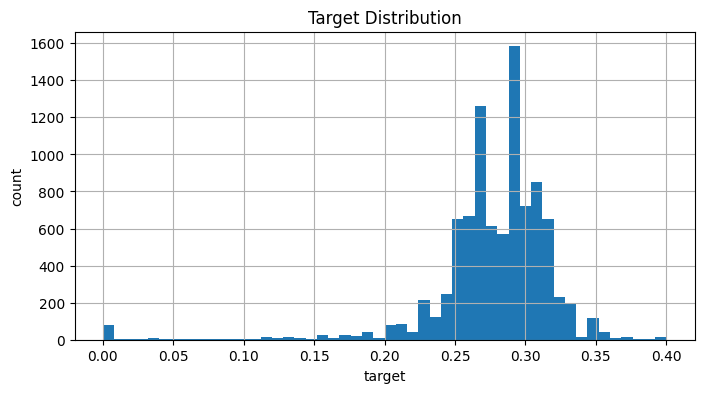

In [5]:
targets = np.array([s["target"] for s in samples], dtype=np.float32)

print("count =", len(targets))
print("min   =", targets.min())
print("max   =", targets.max())
print("mean  =", targets.mean())
print("std   =", targets.std())

plt.figure(figsize=(8, 4))
plt.hist(targets, bins=50)
plt.title("Target Distribution")
plt.xlabel("target")
plt.ylabel("count")
plt.grid(True)
plt.show()

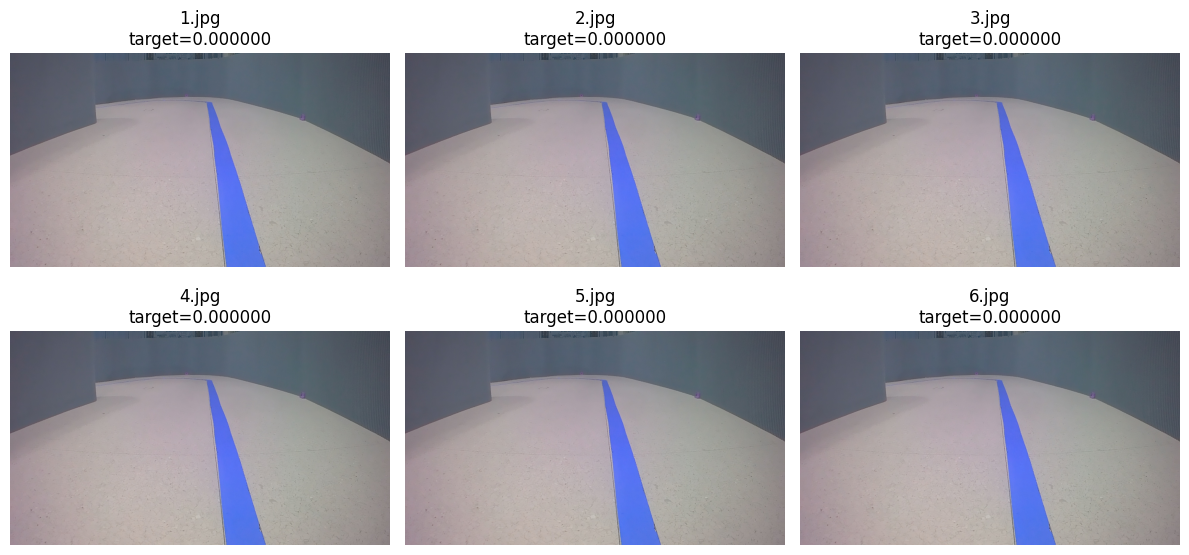

In [6]:
sample_n = min(6, len(samples))
fig, axes = plt.subplots(2, 3, figsize=(12, 6))
axes = axes.flatten()

for i in range(sample_n):
    row = samples[i]
    img = Image.open(row["full_path"]).convert("RGB")
    axes[i].imshow(img)
    axes[i].set_title(f'{row["image_name"]}\ntarget={row["target"]:.6f}')
    axes[i].axis("off")

for j in range(sample_n, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

In [7]:
class SteeringDataset(Dataset):
    def __init__(self, samples):
        self.samples = samples

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        row = self.samples[idx]

        img = Image.open(row["full_path"]).convert("RGB")
        img = np.array(img)  # (H, W, C), uint8

        image = torch.from_numpy(img)  # HWC
        target = torch.tensor([row["target"]], dtype=torch.float32)

        return image, target

In [8]:
class CNN(nn.Module):
    """
    CNN using kernel sizes:
    5x5, 5x5, 5x5, 3x3, 3x3

    Input before forward processing:
        (N, H, W, C)
    Internal resized input:
        (N, 3, 144, 224)
    Output:
        (N, 1)
    """

    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 24, kernel_size=5, stride=2),
            nn.ReLU(inplace=True),

            nn.Conv2d(24, 36, kernel_size=5, stride=2),
            nn.ReLU(inplace=True),

            nn.Conv2d(36, 48, kernel_size=5, stride=2),
            nn.ReLU(inplace=True),

            nn.Conv2d(48, 64, kernel_size=3, stride=1),
            nn.ReLU(inplace=True),

            nn.Conv2d(64, 64, kernel_size=3, stride=1),
            nn.ReLU(inplace=True),
        )

        # For input 3x144x224 -> conv stack -> 64x11x21
        self.flatten_dim = 64 * 11 * 21

        self.classifier = nn.Sequential(
            nn.Linear(self.flatten_dim, 100),
            nn.ReLU(inplace=True),

            nn.Linear(100, 50),
            nn.ReLU(inplace=True),

            nn.Linear(50, 10),
            nn.ReLU(inplace=True),

            nn.Linear(10, 1),
        )

    def forward(self, x):
        # x: (N, H, W, C)
        x = x.permute(0, 3, 1, 2).float()  # -> (N, C, H, W)

        if x.shape[-2:] != (INPUT_HEIGHT, INPUT_WIDTH):
            x = F.interpolate(
                x,
                size=(INPUT_HEIGHT, INPUT_WIDTH),
                mode='bilinear',
                align_corners=False
            )

        # normalize to [-1, 1]
        x = x / 255.0
        x = x * 2.0 - 1.0

        x = self.features(x)
        x = x.reshape(x.size(0), -1)
        x = self.classifier(x)
        return x

In [9]:
torch.manual_seed(RANDOM_SEED)

dataset = SteeringDataset(samples)

train_size = int(TRAIN_RATIO * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(
    dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(RANDOM_SEED)
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

print("train size =", len(train_dataset))
print("val size   =", len(val_dataset))

train size = 7446
val size   = 1862


In [10]:
def train_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0

    for images, targets in dataloader:
        images = images.to(device)
        targets = targets.to(device)

        preds = model(images)
        loss = criterion(preds, targets).mean()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(dataloader)


def val_epoch(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0.0

    with torch.no_grad():
        for images, targets in dataloader:
            images = images.to(device)
            targets = targets.to(device)

            preds = model(images)
            loss = criterion(preds, targets).mean()

            total_loss += loss.item()

    return total_loss / len(dataloader)

In [11]:
class EarlyStopCriterion:
    def __init__(self):
        self.best_val_loss = float("inf")

    def __call__(self, train_loss, val_loss):
        improved = val_loss < self.best_val_loss
        if improved:
            self.best_val_loss = val_loss
        return improved

In [12]:
def plot_loss_curve(train_loss_list, val_loss_list):
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(train_loss_list, label="train")
    ax.plot(val_loss_list, label="val")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.set_title("Training / Validation Loss")
    ax.grid(True)
    ax.legend()
    return fig, ax

In [13]:
model = CNN().to(DEVICE)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

criterion = nn.MSELoss(reduction='none')
early_stop = EarlyStopCriterion()

train_loss_list = []
val_loss_list = []

best_model_path = RESULT_FOLDER / "best.pt"

pbar = tqdm(range(1, NUM_EPOCHS + 1), desc="Training CNN Controller")

for epoch in pbar:
    train_loss = train_epoch(model, train_loader, criterion, optimizer, DEVICE)
    val_loss = val_epoch(model, val_loader, criterion, DEVICE)

    if early_stop(train_loss, val_loss):
        torch.save(model.state_dict(), best_model_path)
        tqdm.write(f"Saved best model at epoch {epoch}")

    train_loss_list.append(train_loss)
    val_loss_list.append(val_loss)

    pbar.set_postfix(
        train_loss=f"{train_loss:.6f}",
        val_loss=f"{val_loss:.6f}"
    )

print("Training finished.")
print("Best model saved to:", best_model_path)

Training CNN Controller:   1%|          | 1/100 [01:07<1:52:09, 67.97s/it, train_loss=0.004902, val_loss=0.001955]

Saved best model at epoch 1


Training CNN Controller:   4%|▍         | 4/100 [03:47<1:28:03, 55.03s/it, train_loss=0.001901, val_loss=0.001932]

Saved best model at epoch 4


Training CNN Controller:   5%|▌         | 5/100 [04:39<1:25:34, 54.05s/it, train_loss=0.001907, val_loss=0.001926]

...

Saved best model at epoch 96


Training CNN Controller:  97%|█████████▋| 97/100 [1:27:22<02:49, 56.36s/it, train_loss=0.001294, val_loss=0.001665]

Saved best model at epoch 97


Training CNN Controller: 100%|██████████| 100/100 [1:30:11<00:00, 54.12s/it, train_loss=0.001510, val_loss=0.001724]

Training finished.
Best model saved to: cnn_2026_03_10_21_10_09/best.pt


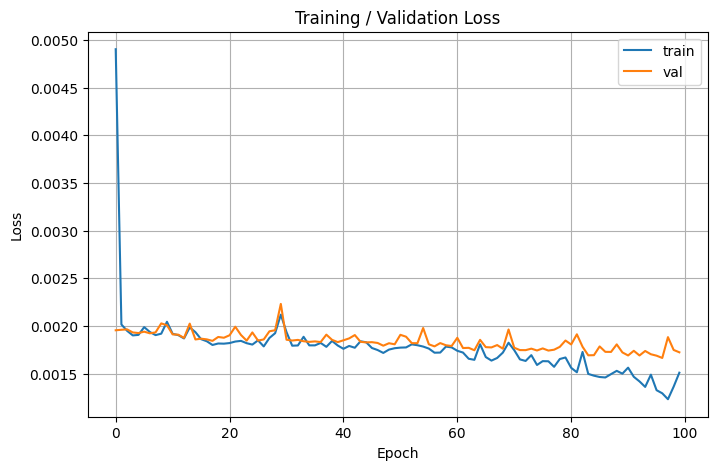

In [14]:
fig, ax = plot_loss_curve(train_loss_list, val_loss_list)
fig.savefig(RESULT_FOLDER / "loss_curve.png", dpi=200, bbox_inches="tight")
plt.show()

In [15]:
best_model = CNN().to(DEVICE)
best_model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))
best_model.eval()

images, targets = next(iter(val_loader))
images = images.to(DEVICE)
targets = targets.to(DEVICE)

with torch.no_grad():
    preds = best_model(images)

print("pred shape:", preds.shape)
print("target shape:", targets.shape)

for i in range(min(10, len(images))):
    print(f"{i}: pred={preds[i].item():.6f}, target={targets[i].item():.6f}")

pred shape: torch.Size([256, 1])
target shape: torch.Size([256, 1])
0: pred=0.258045, target=0.268546
1: pred=0.228180, target=0.000000
2: pred=0.287135, target=0.315139
3: pred=0.229758, target=0.261889
4: pred=0.274278, target=0.291842
5: pred=0.263792, target=0.281858
6: pred=0.285678, target=0.231923
7: pred=0.293105, target=0.261889
8: pred=0.301652, target=0.345092
9: pred=0.283760, target=0.315139
